In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

/home/pawan/anaconda3/envs/langchain/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class QuadState(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant: int
    
    root1: float
    root2: float

In [3]:
graph = StateGraph(QuadState)

In [4]:
def get_equation(state: QuadState):

    equation = f"({state['a']})x^2 + ({state['b']})x + ({state['c']})"

    return {'equation': equation}

def get_discriminant(state: QuadState):

    discriminant = (state['b'] ** 2) - (4 * state['a'] * state['c'])

    return {'discriminant': discriminant}

def get_real_roots(state: QuadState):

    root1 = (- state['b'] - state['discriminant']**0.5) / (2 * state['a'])
    root2 = (- state['b'] + state['discriminant']**0.5) / (2 * state['a'])

    return {'root1': root1, 'root2': root2}

def get_repeated_real_roots(state: QuadState):

    root = (- state['b']) / (2 * state['a'])

    return {'root1': root, 'root2': root}

def no_real_roots(state: QuadState):

    root = None

    return {'root1': root, 'root2': root}

In [5]:
def check_condition(state: QuadState) -> Literal['get_real_roots', 'get_repeated_real_roots', 'no_real_roots']:

    if state['discriminant'] > 0:
        return 'get_real_roots'
    elif state['discriminant'] == 0:
        return 'get_repeated_real_roots'
    else:
        return 'no_real_roots'

In [6]:
graph.add_node('get_equation', get_equation)
graph.add_node('get_discriminant', get_discriminant)
graph.add_node('get_real_roots', get_real_roots)
graph.add_node('get_repeated_real_roots', get_repeated_real_roots)
graph.add_node('no_real_roots', no_real_roots)

In [7]:
graph.add_edge(START, 'get_equation')
graph.add_edge('get_equation', 'get_discriminant')
graph.add_conditional_edges('get_discriminant', check_condition)
graph.add_edge('get_real_roots', END)
graph.add_edge('get_repeated_real_roots', END)
graph.add_edge('no_real_roots', END)

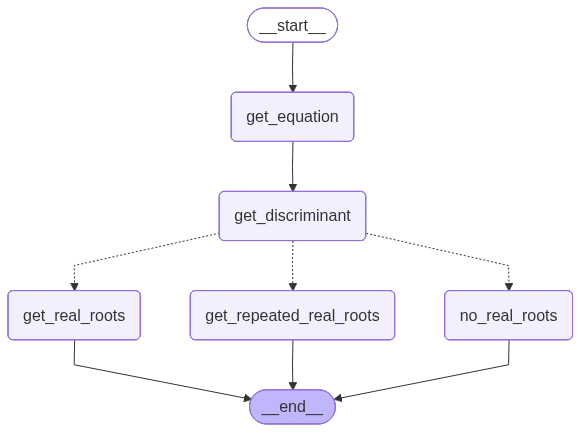

In [8]:
workflow = graph.compile()
workflow

In [11]:
initial_state = {'a': 1, 'b': 2, 'c': -3}
workflow.invoke(initial_state)

{'a': 1,
 'b': 2,
 'c': -3,
 'equation': '(1)x^2 + (2)x + (-3)',
 'discriminant': 16,
 'root1': -3.0,
 'root2': 1.0}